In [87]:
import math 
class Value:
        
    def __init__(self,data, _children= (), _op='', label =''):
        self.data = data 
        self.grad = 0.0
        self._backward = lambda : None
        self._prev = set(_children)
        self._op = _op 
        self.label = label

            
    def __repr__(self):
        return f"Value(data = {self.data})"
    

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')

        def _backward():
            self.grad += out.grad 
            other.grad += out.grad 

        out._backward = _backward
        return out 
    
    def __radd__(self, other):
        return self+ other
    
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), "*")

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad

        out._backward = _backward
        return out

    def __rmul__(self, other):
        return self  * other
    
    def __neg__(self):
        return self * -1 
    

    def __sub__(self, other):
        return self + (-other)
    
    def __rsub__(self, other):
        return other + (-self)
    
    def __pow__(self, other):
        assert isinstance(other, (int, float))
        out = Value(self.data ** other, (self,), f'**{other}')

        def _backward():
            self.grad += other * (self.data ** (other - 1)) * out.grad  

        out._backward = _backward
        return out 
    
    def __truediv__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        return self * other **-1
    
    def __rtruediv__(self, other):
        return other * self **-1
    
    
    def tanh(self):
        x = self.data 
        t = (math.exp(2 * x) -1) / (math.exp(2 * x) + 1)
        out = Value(t, (self,), 'tanh')

        def _backward():
            self.grad += ( 1- t**2)* out.grad 

        out._backward = _backward
        return out 
    
    
    
    def backward(self):
            topo = []
            vistited = set()
            def build_topo(v):
                if v not in vistited:
                    vistited.add(v)
                    for child in v._prev:
                        build_topo(child)
                    topo.append(v)
            build_topo(self)

            self.grad = 1.0
            for node in reversed(topo):
                node._backward()



    

        





    

        
# a = Value(20.99, label='a')
# b = Value(-222,  label='b')
# a.__add__(b)
# c = Value(10.0, label='c')
# x = a * b
# x.label = 'x'
# d = x + c
# d.label = 'd'
# e = c * d
# e.label = 'e'
# L = e * f
# L.label = 'L'


In [88]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

In [89]:
# L.grad = 1.0
# e.grad = -2
# f.grad = -4649.80
# d.grad = -20
# c.grad = 9279.56
# x.grad = -20
# a.grad =-419.8
# b.grad = 4440

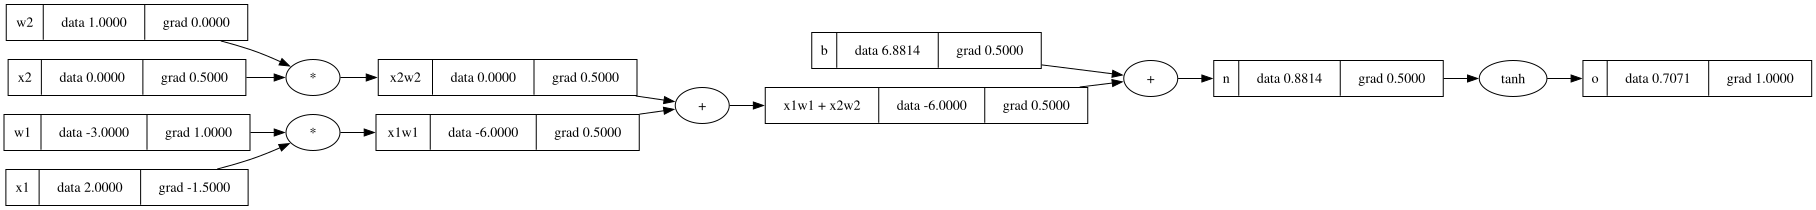

In [90]:
# inputs 
# inputs
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

# weights
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

# bias
b = Value(6.8813735870195432, label='b')

x1w1 = x1*w1
x1w1.label = "x1w1"
x2w2 = x2*w2
x2w2.label = "x2w2"
x1w1x2w2 = x1w1 + x2w2 
x1w1x2w2.label = 'x1w1 + x2w2'
n = x1w1x2w2 + b
n.label = 'n'
o = n.tanh()
o.label = 'o'

# o.grad = 1.0
# n.grad = 0.5
# b.grad = 0.5
# x1w1x2w2.grad = 0.5
# x2w2.grad = 0.5
# x1w1.grad = 0.5
# x1.grad = -1.5
# w1.grad = 1
# x2.grad = 0.5
# w2.grad = 0


# o.grad = 1.0
# o._backward()
# n._backward()
# x1w1x2w2._backward()
# x1w1._backward()
# x2w2._backward()

o.backward()

draw_dot(o)



In [91]:
import random
class Neuron:

    def __init__(self, nin):
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1,1))
    
    def __call__(self, x):
        act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
        out = act.tanh()
        return out 
    
    def parameters(self):
        return self.w + [self.b]



class Layer:

    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs


    def parameters(self):
        params = []
        for neuron in self.neurons:
            ps = neuron.parameters()
            params.extend(ps)
        return params

    
    

class MLP:

    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))] 

    def __call__(self,x):
        for layer in self.layers:
            x = layer(x)
        return x 
    
    def parameters(self):
        params = []
        for layer in self.layers:
            ps = layer.parameters()
            params.extend(ps)
        return params

    

x = [2.0, 3.0, -1.0]
n = MLP(3, [4,4,1])
        
                

In [92]:
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0]
out = n(x)
ypred = [n(x) for x  in xs ]
ypred

[Value(data = 0.10127968020103133),
 Value(data = 0.3515138662543444),
 Value(data = 0.2073449852459074),
 Value(data = 0.21414984043327112)]

In [98]:
print(len(n.parameters()))

41


In [100]:
print(loss)

Value(data = 0.8076982132195606)


In [101]:
loss.backward()